In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import History
import seaborn as sns

# **1. MNIST dataset**

## **Loading the data**

In [4]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train, x_val = x_train[:-5000], x_train[-5000:]
y_train, y_val = y_train[:-5000], y_train[-5000:]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)


x_train shape: (55000, 28, 28)
y_train shape: (55000,)
x_val shape: (5000, 28, 28)
y_val shape: (5000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


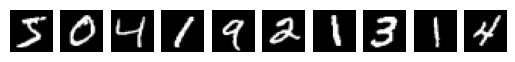

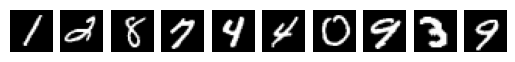

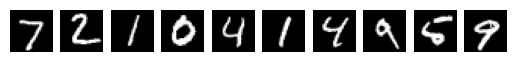

In [6]:
# visualize the first 10 images of each set
fig, axs = plt.subplots(1, 10)
for i in range(10):
    axs[i].imshow(x_train[i], cmap='gray')
    axs[i].axis('off')
plt.show()

fig, axs = plt.subplots(1, 10)
for i in range(10):
    axs[i].imshow(x_val[i], cmap='gray')
    axs[i].axis('off')
plt.show()

fig, axs = plt.subplots(1, 10)
for i in range(10):
    axs[i].imshow(x_test[i], cmap='gray')
    axs[i].axis('off')
plt.show()


## **1.1**

Epoch 1/10
1719/1719 [==============================] - 12s 4ms/step - loss: 0.1406 - accuracy: 0.9566 - val_loss: 0.0426 - val_accuracy: 0.9872
Epoch 2/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.0448 - accuracy: 0.9861 - val_loss: 0.0436 - val_accuracy: 0.9896
Epoch 3/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.0308 - accuracy: 0.9900 - val_loss: 0.0412 - val_accuracy: 0.9892
Epoch 4/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.0219 - accuracy: 0.9929 - val_loss: 0.0403 - val_accuracy: 0.9890
Epoch 5/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.0173 - accuracy: 0.9942 - val_loss: 0.0393 - val_accuracy: 0.9886
Epoch 6/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.0122 - accuracy: 0.9956 - val_loss: 0.0436 - val_accuracy: 0.9904
Epoch 7/10
1719/1719 [==============================] - 5s 3ms/step - loss: 0.0104 - accuracy: 0.9963 - val_loss: 0.0361 - val_accuracy

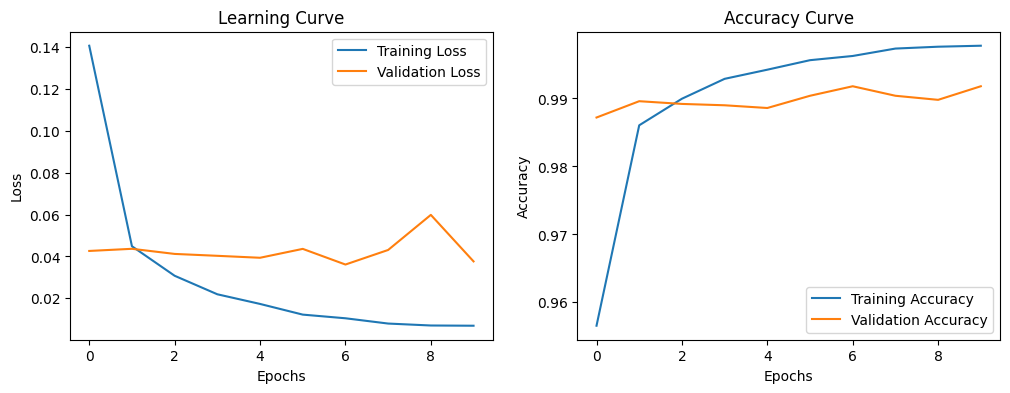

313/313 [==============================] - 1s 2ms/step - loss: 0.0369 - accuracy: 0.9906
Test Loss: 0.03694189712405205
Test Accuracy: 0.9905999898910522


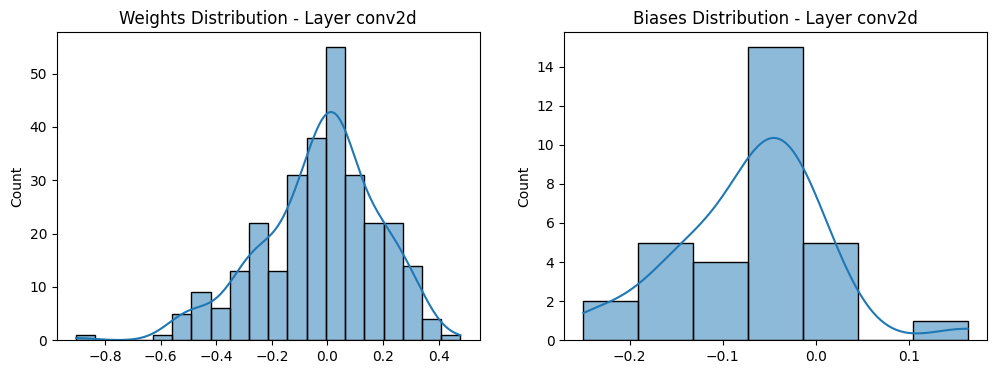

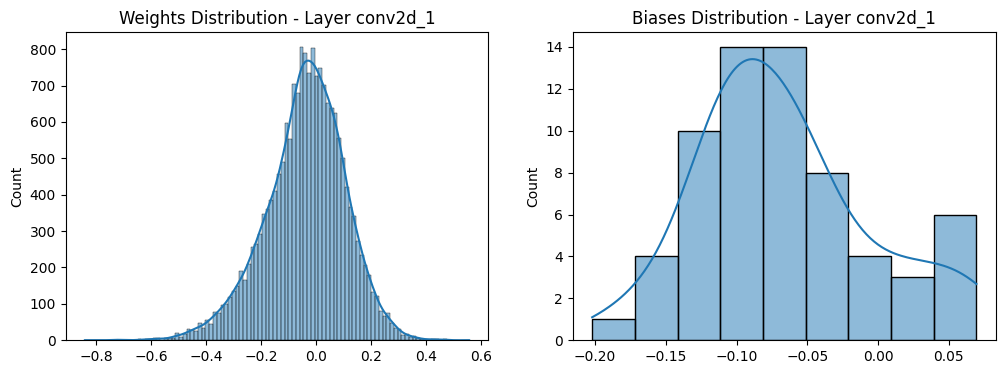

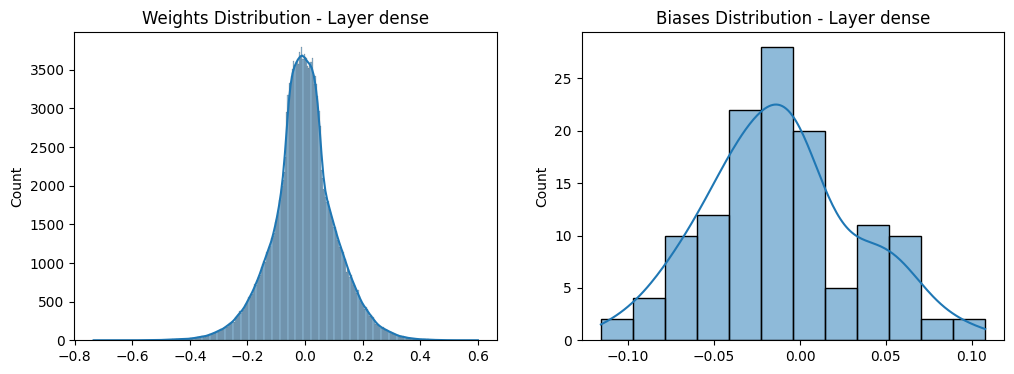

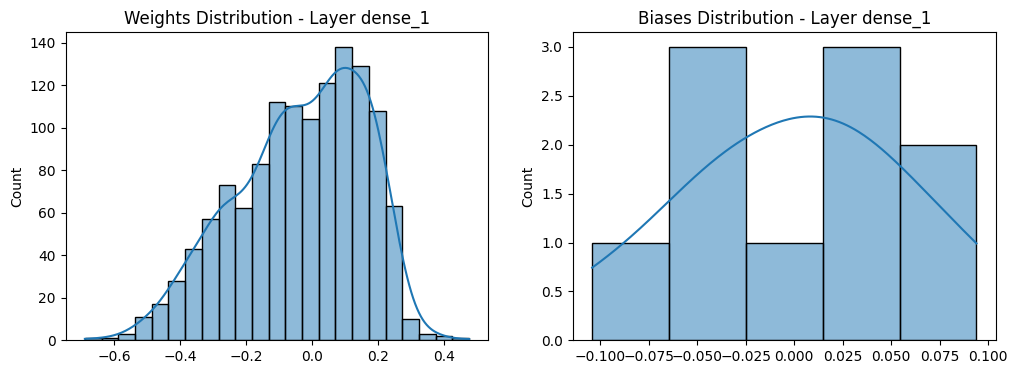

In [7]:


# Define the CNN architecture
def cnn_model(filter_size, stride_size):
    model = Sequential([
        Conv2D(32, kernel_size=filter_size, strides=stride_size, activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, kernel_size=filter_size, strides=stride_size, activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

# Compile the model
filter_size = (3, 3)
stride_size = (1, 1)
model = cnn_model(filter_size, stride_size)
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train[..., np.newaxis], y_train, epochs=10, validation_data=(x_val[..., np.newaxis], y_val))

# Plot the learning curve
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curve')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')
plt.show()

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test[..., np.newaxis], y_test)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

# Plot the distributions of weights and biases
for layer in model.layers:
    if isinstance(layer, Conv2D) or isinstance(layer, Dense):
        weights, biases = layer.get_weights()
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        sns.histplot(weights.flatten(), kde=True)
        plt.title(f'Weights Distribution - Layer {layer.name}')
        plt.subplot(1, 2, 2)
        sns.histplot(biases.flatten(), kde=True)
        plt.title(f'Biases Distribution - Layer {layer.name}')
        plt.show()

## **1.2**

313/313 [==============================] - 1s 2ms/step


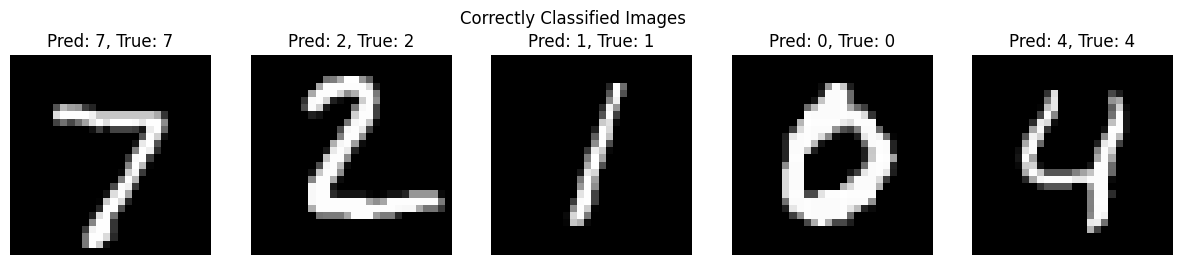

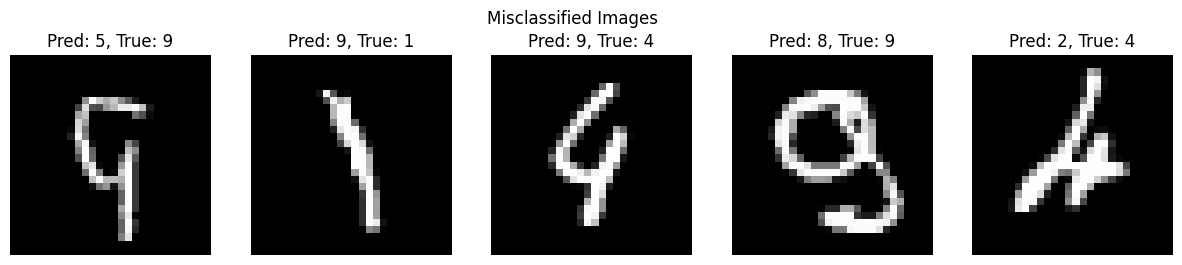

Number of correctly classified images: 9906
Number of misclassified images: 94
Accuracy: 99.06%


In [9]:
# Make predictions on the test set
predictions = model.predict(x_test[..., np.newaxis])
predicted_labels = np.argmax(predictions, axis=1)

# Find correctly classified and misclassified images
correct_indices = np.where(predicted_labels == y_test)[0]
incorrect_indices = np.where(predicted_labels != y_test)[0]

# Plot some correctly classified images
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Correctly Classified Images')
for i, idx in enumerate(correct_indices[:5]):
    axs[i].imshow(x_test[idx], cmap='gray')
    axs[i].set_title(f'Pred: {predicted_labels[idx]}, True: {y_test[idx]}')
    axs[i].axis('off')
plt.show()

# Plot some misclassified images
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Misclassified Images')
for i, idx in enumerate(incorrect_indices[:5]):
    axs[i].imshow(x_test[idx], cmap='gray')
    axs[i].set_title(f'Pred: {predicted_labels[idx]}, True: {y_test[idx]}')
    axs[i].axis('off')
plt.show()


print(f'Number of correctly classified images: {len(correct_indices)}')
print(f'Number of misclassified images: {len(incorrect_indices)}')
print(f'Accuracy: {len(correct_indices) / len(y_test) * 100:.2f}%')

## **1.3**

1/1 [==============================] - 0s 50ms/step


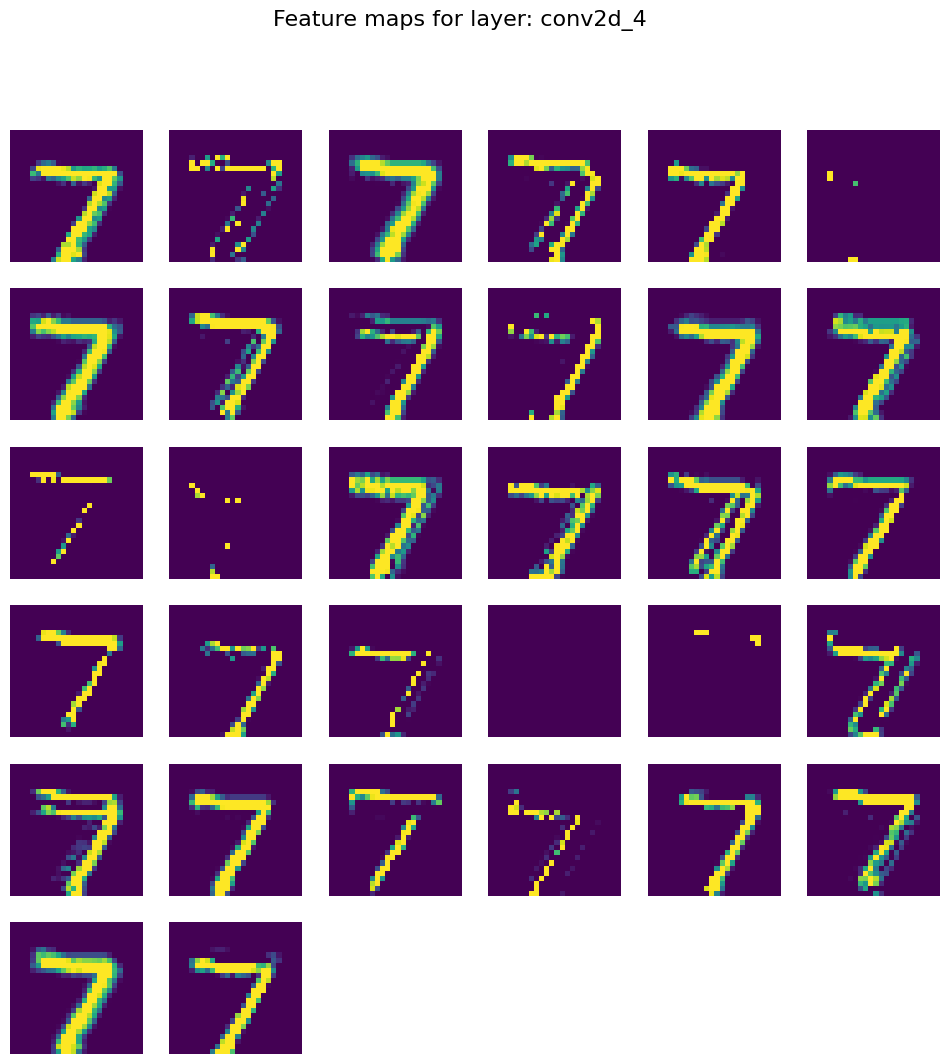

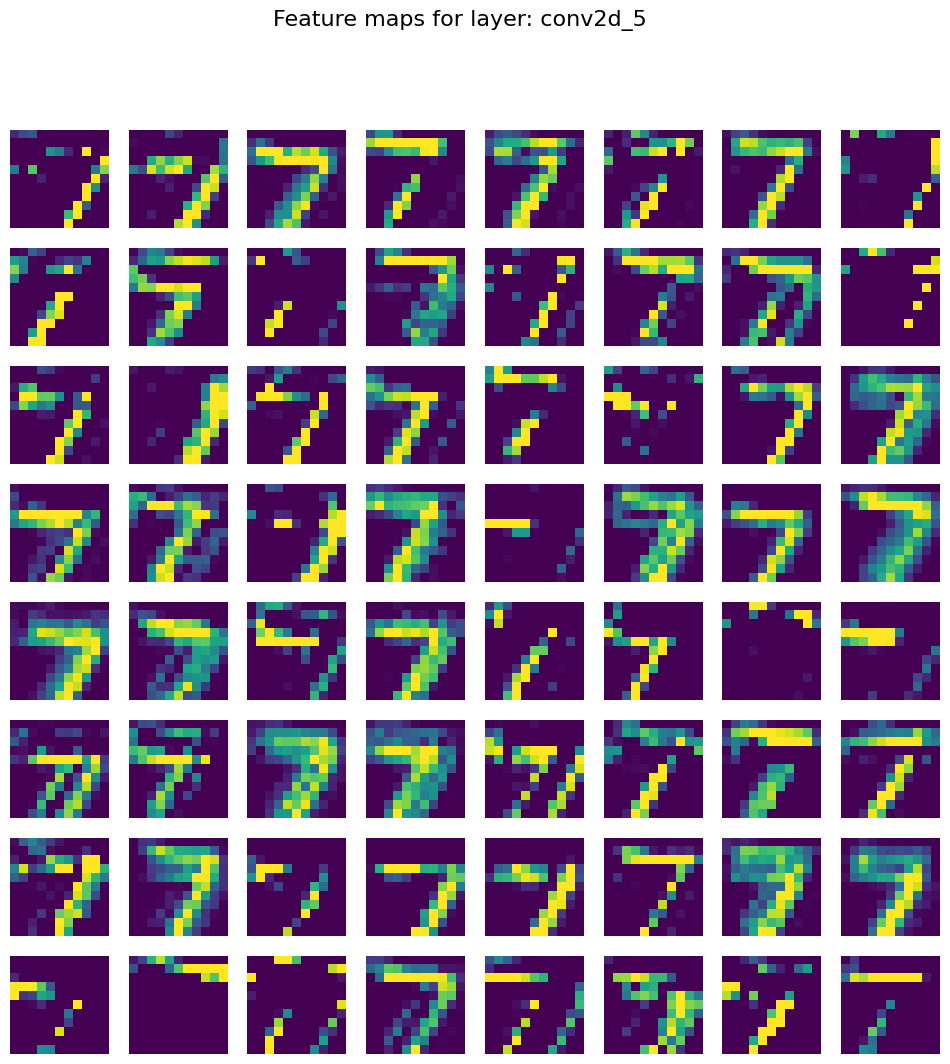

As the depth of the convolutional layers increases, the feature maps tend to become more abstract and less visually interpretable. The initial layers capture low-level features such as edges and textures, while the deeper layers capture high-level features and patterns that are more specific to the task at hand.


In [11]:
from tensorflow.keras.layers import Input

# Define the CNN architecture with explicit input
# note: I did that because I couldn't get the feature maps without it, the activation model won't work even when I use the right input, this is the solution I found
def cnn_model(filter_size, stride_size):
    input_layer = Input(shape=(28, 28, 1))
    x = Conv2D(32, kernel_size=filter_size, strides=stride_size, activation='relu')(input_layer)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Conv2D(64, kernel_size=filter_size, strides=stride_size, activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    output_layer = Dense(10, activation='softmax')(x)
    
    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
    return model

# Compile the model
filter_size = (3, 3)
stride_size = (1, 1)
model = cnn_model(filter_size, stride_size)
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Dummy call to initialize model (optional with explicit input layer)
_ = model(np.random.rand(1, 28, 28, 1))

# Create a new model that outputs the feature maps of the intermediate layers
layer_outputs = [layer.output for layer in model.layers if isinstance(layer, Conv2D)]
activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)

# Get the feature maps for a sample image from the test set
sample_image = x_test[0][..., np.newaxis]
sample_image = np.expand_dims(sample_image, axis=0)
feature_maps = activation_model.predict(sample_image)

# Plot the feature maps in a grid
for layer_name, feature_map in zip([layer.name for layer in model.layers if isinstance(layer, Conv2D)], feature_maps):
    num_filters = feature_map.shape[-1]
    size = feature_map.shape[1]

 
    grid_size = int(np.ceil(np.sqrt(num_filters)))  

    fig, axs = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    fig.suptitle(f"Feature maps for layer: {layer_name}", fontsize=16)

    for i in range(num_filters):
        row, col = divmod(i, grid_size)
        ax = axs[row, col]
        
        # Extract and normalize the feature map for display
        x = feature_map[0, :, :, i]
        x -= x.mean()
        x /= (x.std() + 1e-5)  
        x *= 64
        x += 128
        x = np.clip(x, 0, 255).astype('uint8')
        
        # Plot on the grid
        ax.imshow(x, aspect='auto', cmap='viridis')
        ax.axis('off')
    
    
    for j in range(i + 1, grid_size * grid_size):
        row, col = divmod(j, grid_size)
        axs[row, col].axis('off')
    
    plt.show()




## **1.4**

Epoch 1/10
1719/1719 [==============================] - 9s 5ms/step - loss: 0.6628 - accuracy: 0.9291 - val_loss: 0.4434 - val_accuracy: 0.9646
Epoch 2/10
1719/1719 [==============================] - 7s 4ms/step - loss: 0.4705 - accuracy: 0.9497 - val_loss: 0.4134 - val_accuracy: 0.9682
Epoch 3/10
1719/1719 [==============================] - 6s 4ms/step - loss: 0.4516 - accuracy: 0.9533 - val_loss: 0.4226 - val_accuracy: 0.9622
Epoch 4/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4443 - accuracy: 0.9538 - val_loss: 0.4097 - val_accuracy: 0.9650
Epoch 5/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4388 - accuracy: 0.9556 - val_loss: 0.3989 - val_accuracy: 0.9694
Epoch 6/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4344 - accuracy: 0.9551 - val_loss: 0.3985 - val_accuracy: 0.9678
Epoch 7/10
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4325 - accuracy: 0.9555 - val_loss: 0.4065 - val_accuracy:

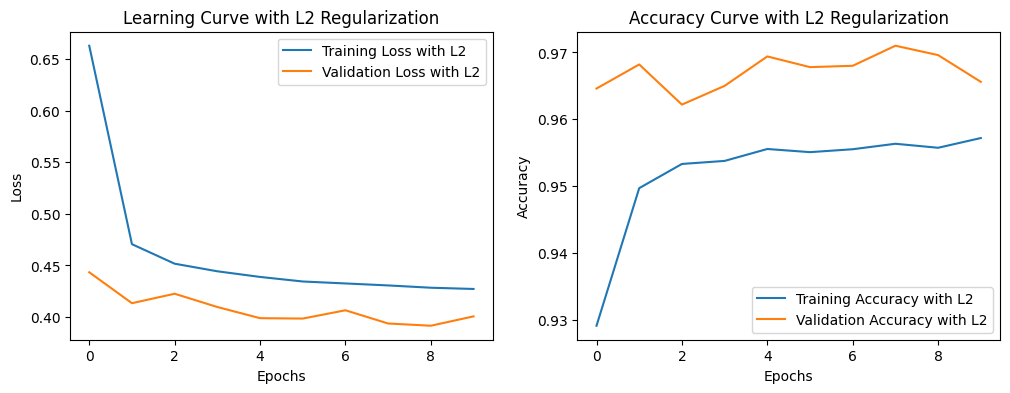

313/313 [==============================] - 1s 2ms/step - loss: 0.4196 - accuracy: 0.9572
Test Loss with L2: 0.4195922017097473
Test Accuracy with L2: 0.9571999907493591
L2 regularization adds a penalty to the loss function proportional to the sum of the squared weights. This helps to prevent overfitting by discouraging the model from learning overly complex patterns that may not generalize well to new data. As a result, the model with L2 regularization may have slightly higher training loss but improved validation and test performance, indicating better generalization.


In [12]:
from tensorflow.keras.regularizers import l2

# Define the CNN architecture with L2 regularization
def cnn_model_with_l2(filter_size, stride_size, l2_lambda):
    input_layer = Input(shape=(28, 28, 1))
    x = Conv2D(32, kernel_size=filter_size, strides=stride_size, activation='relu', kernel_regularizer=l2(l2_lambda))(input_layer)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Conv2D(64, kernel_size=filter_size, strides=stride_size, activation='relu', kernel_regularizer=l2(l2_lambda))(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(l2_lambda))(x)
    output_layer = Dense(10, activation='softmax', kernel_regularizer=l2(l2_lambda))(x)
    
    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
    return model

# Compile the model with L2 regularization
l2_lambda = 0.01
model_l2 = cnn_model_with_l2(filter_size, stride_size, l2_lambda)
model_l2.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model with L2 regularization
history_l2 = model_l2.fit(x_train[..., np.newaxis], y_train, epochs=10, validation_data=(x_val[..., np.newaxis], y_val))

# Plot the learning curve with L2 regularization
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_l2.history['loss'], label='Training Loss with L2')
plt.plot(history_l2.history['val_loss'], label='Validation Loss with L2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curve with L2 Regularization')

plt.subplot(1, 2, 2)
plt.plot(history_l2.history['accuracy'], label='Training Accuracy with L2')
plt.plot(history_l2.history['val_accuracy'], label='Validation Accuracy with L2')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve with L2 Regularization')
plt.show()

# Evaluate the model with L2 regularization on the test set
test_loss_l2, test_accuracy_l2 = model_l2.evaluate(x_test[..., np.newaxis], y_test)
print(f'Test Loss with L2: {test_loss_l2}')
print(f'Test Accuracy with L2: {test_accuracy_l2}')

# Discuss the effect of L2 regularization
print("L2 regularization adds a penalty to the loss function proportional to the sum of the squared weights. This helps to prevent overfitting by discouraging the model from learning overly complex patterns that may not generalize well to new data. As a result, the model with L2 regularization may have slightly higher training loss but improved validation and test performance, indicating better generalization.")

# **CIFAR-10 DATASET**

Training data shape: (45000, 32, 32, 3)
Training labels shape: (45000,)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000,)
Validation data shape: (5000, 32, 32, 3)
Validation labels shape: (5000,)


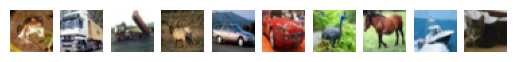

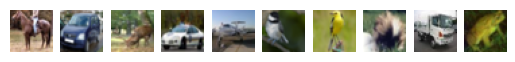

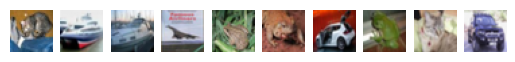

In [48]:
import pickle
import numpy as np

# Function to load a batch file
def load_batch(file):
    with open(file, 'rb') as fo:
        data_dict = pickle.load(fo, encoding='bytes')
        # Decode the byte keys to strings 
        data = data_dict[b'data']
        labels = data_dict[b'labels']
        data = data.reshape(len(data), 3, 32, 32).transpose(0, 2, 3, 1)  # Reshape and reorder dimensions
        labels = np.array(labels)
        return data, labels

# Load all training batches
train_data = []
train_labels = []
for i in range(1, 6):
    file = f'cifar-10-batches-py/data_batch_{i}'
    data, labels = load_batch(file)
    train_data.append(data)
    train_labels.append(labels)

# Concatenate the batches
train_data = np.concatenate(train_data)
train_labels = np.concatenate(train_labels)

# divide the training data into training and validation sets, with 5000 samples for validation
val_data, val_labels = train_data[-5000:], train_labels[-5000:]
train_data, train_labels = train_data[:-5000], train_labels[:-5000]

# Load test batch
test_data, test_labels = load_batch('cifar-10-batches-py/test_batch')

print(f"Training data shape: {train_data.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Validation data shape: {val_data.shape}")
print(f"Validation labels shape: {val_labels.shape}")

# preprocess the data
train_data = train_data / 255.0
val_data = val_data / 255.0
test_data = test_data / 255.0



# Visualize the first 10 images of each set
fig, axs = plt.subplots(1, 10)
for i in range(10):
    axs[i].imshow(train_data[i])
    axs[i].axis('off')
plt.show()

fig, axs = plt.subplots(1, 10)
for i in range(10):
    axs[i].imshow(val_data[i])
    axs[i].axis('off')
plt.show()

fig, axs = plt.subplots(1, 10)
for i in range(10):
    axs[i].imshow(test_data[i])
    axs[i].axis('off')
plt.show()



In [43]:
train_labels

array([6, 9, 9, ..., 1, 5, 6])

## **2.1**

Epoch 1/10
1407/1407 [==============================] - 9s 6ms/step - loss: 1.7358 - accuracy: 0.3566 - val_loss: 1.3264 - val_accuracy: 0.5326
Epoch 2/10
1407/1407 [==============================] - 8s 6ms/step - loss: 1.3837 - accuracy: 0.5042 - val_loss: 1.1302 - val_accuracy: 0.6058
Epoch 3/10
1407/1407 [==============================] - 8s 5ms/step - loss: 1.2447 - accuracy: 0.5590 - val_loss: 1.0154 - val_accuracy: 0.6430
Epoch 4/10
1407/1407 [==============================] - 8s 6ms/step - loss: 1.1416 - accuracy: 0.5986 - val_loss: 1.0173 - val_accuracy: 0.6378
Epoch 5/10
1407/1407 [==============================] - 8s 6ms/step - loss: 1.0787 - accuracy: 0.6240 - val_loss: 0.9417 - val_accuracy: 0.6650
Epoch 6/10
1407/1407 [==============================] - 8s 6ms/step - loss: 1.0277 - accuracy: 0.6418 - val_loss: 0.8176 - val_accuracy: 0.7126
Epoch 7/10
1407/1407 [==============================] - 29s 20ms/step - loss: 0.9853 - accuracy: 0.6597 - val_loss: 0.8154 - val_accurac

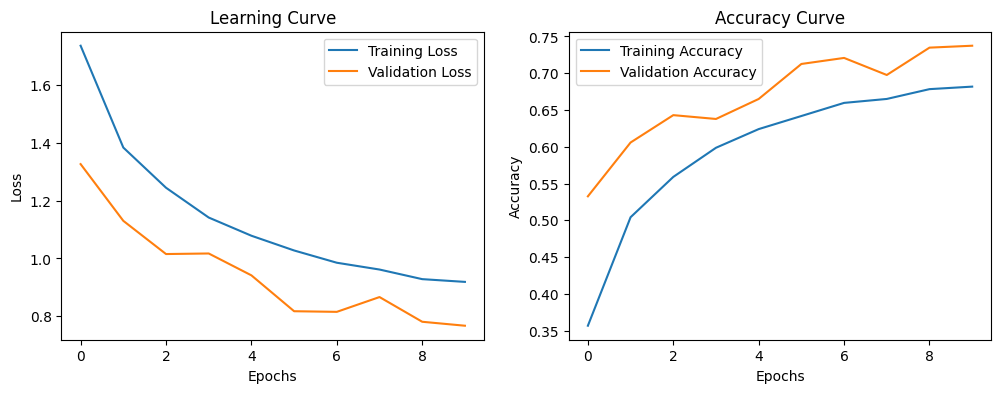

313/313 [==============================] - 1s 3ms/step - loss: 0.7836 - accuracy: 0.7245
Test Loss: 0.783595860004425
Test Accuracy: 0.7245000004768372


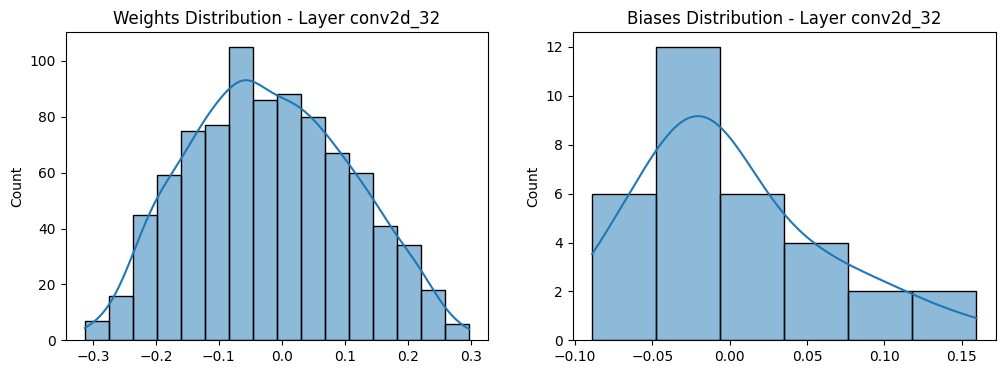

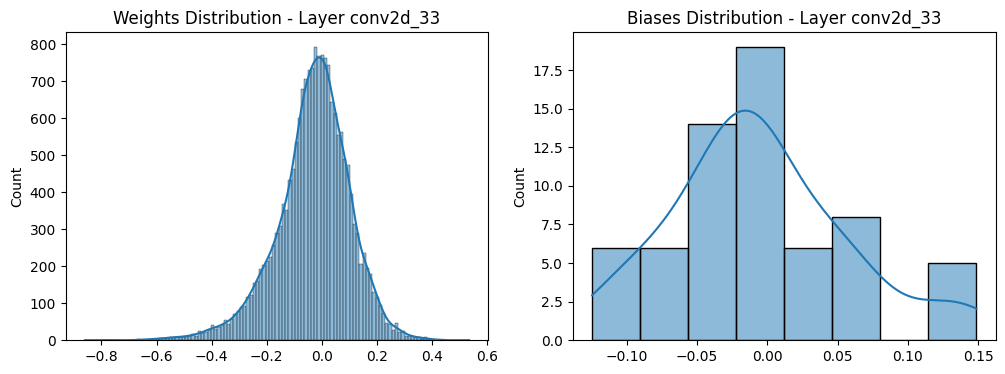

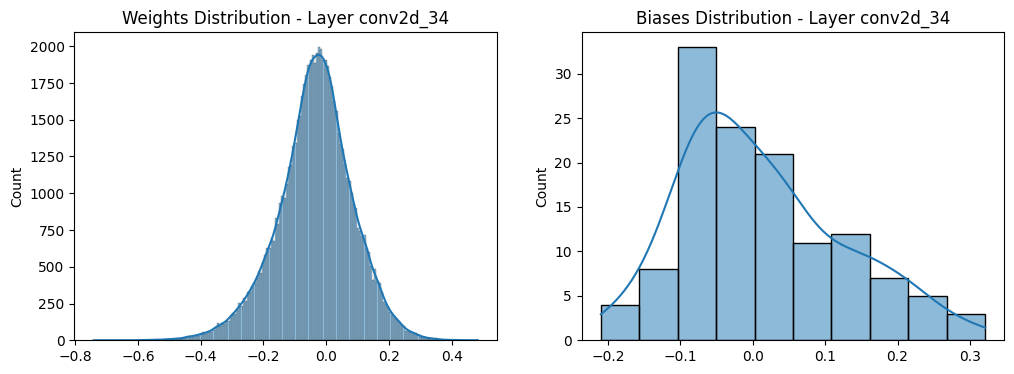

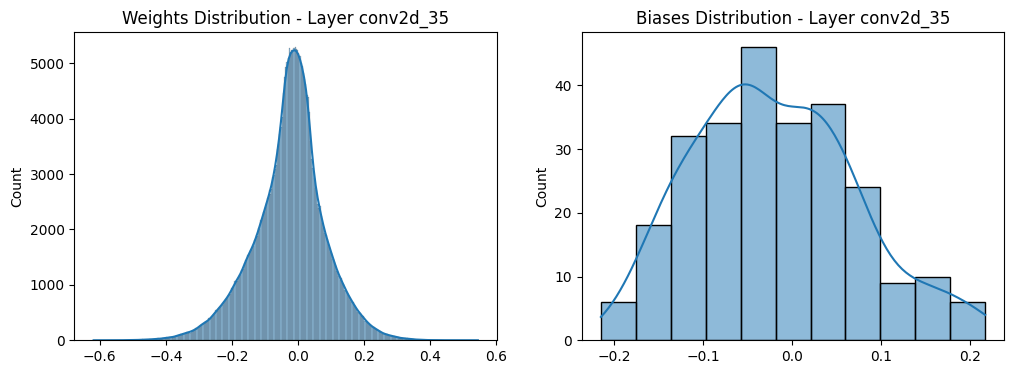

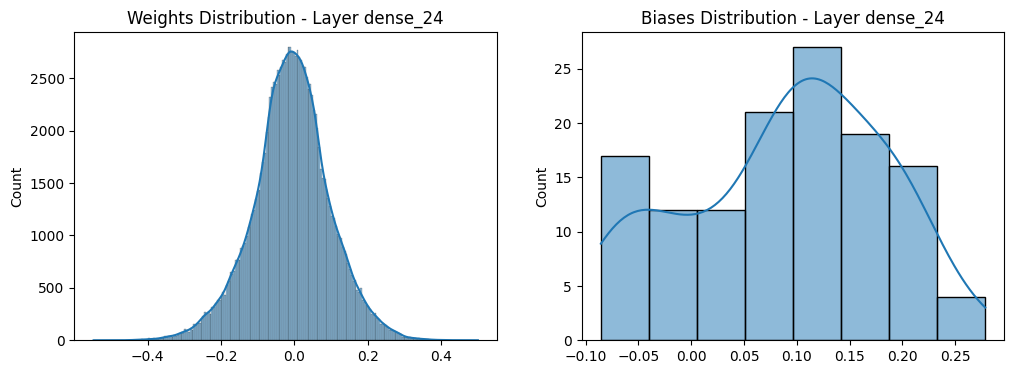

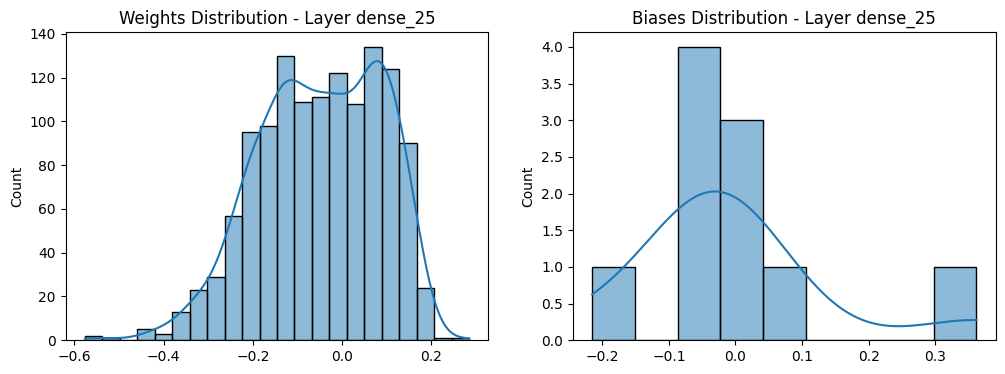

In [40]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import seaborn as sns

# Define the CNN architecture for CIFAR-10 with Dropout
def cnn_model_cifar10(filter_size, stride_size):
    input_layer = Input(shape=(32, 32, 3))
    x = Conv2D(32, kernel_size=filter_size, strides=stride_size, activation='relu', padding='same')(input_layer)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    x = Conv2D(64, kernel_size=filter_size, strides=stride_size, activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    x = Conv2D(128, kernel_size=filter_size, strides=stride_size, activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    x = Conv2D(256, kernel_size=filter_size, strides=stride_size, activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output_layer = Dense(10, activation='softmax')(x)
    
    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
    return model

# Compile the model
filter_size = (3, 3)
stride_size = (1, 1)
model_cifar10 = cnn_model_cifar10(filter_size, stride_size)
model_cifar10.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model_cifar10.fit(train_data, train_labels, epochs=10, validation_data=(val_data, val_labels))

# Plot the learning curve
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curve')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')
plt.show()

# Evaluate the model on the test set
test_loss, test_accuracy = model_cifar10.evaluate(test_data, test_labels)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

# Plot the distributions of weights and biases
for layer in model_cifar10.layers:
    if isinstance(layer, Conv2D) or isinstance(layer, Dense):
        weights, biases = layer.get_weights()
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        sns.histplot(weights.flatten(), kde=True)
        plt.title(f'Weights Distribution - Layer {layer.name}')
        plt.subplot(1, 2, 2)
        sns.histplot(biases.flatten(), kde=True)
        plt.title(f'Biases Distribution - Layer {layer.name}')
        plt.show()

## **2.2**

313/313 [==============================] - 1s 2ms/step


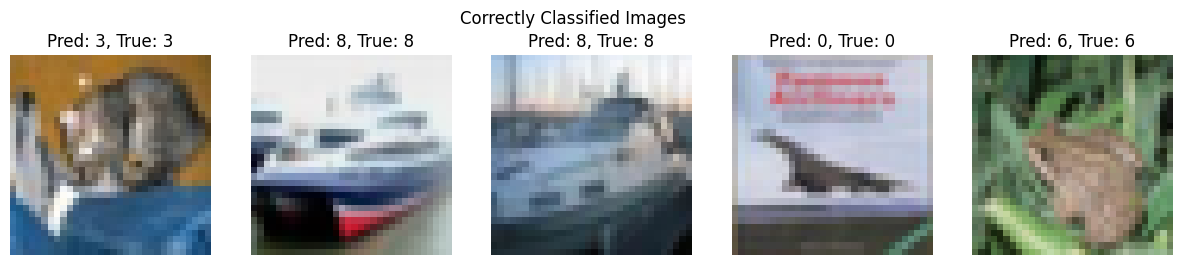

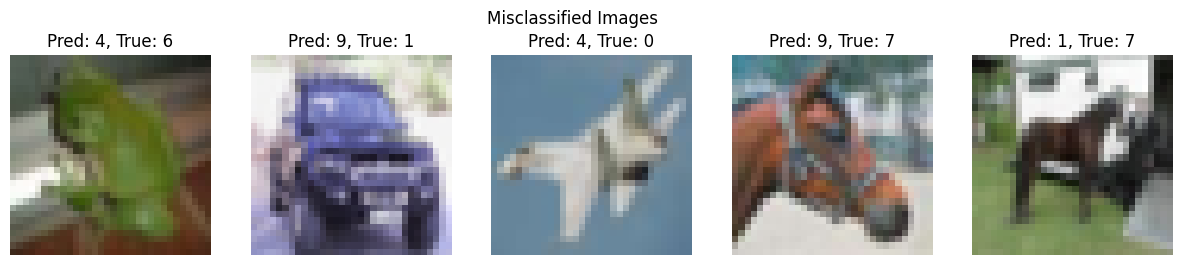

Number of correctly classified images: 7245
Number of misclassified images: 2755
Accuracy: 72.45%


In [41]:
# Make predictions on the test set
predictions = model_cifar10.predict(test_data)
predicted_labels = np.argmax(predictions, axis=1)

# Find correctly classified and misclassified images
correct_indices = np.where(predicted_labels == test_labels)[0]
incorrect_indices = np.where(predicted_labels != test_labels)[0]

# Plot some correctly classified images
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Correctly Classified Images')
for i, idx in enumerate(correct_indices[:5]):
    axs[i].imshow(test_data[idx])
    axs[i].set_title(f'Pred: {predicted_labels[idx]}, True: {test_labels[idx]}')
    axs[i].axis('off')
plt.show()

# Plot some misclassified images
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Misclassified Images')
for i, idx in enumerate(incorrect_indices[:5]):
    axs[i].imshow(test_data[idx])
    axs[i].set_title(f'Pred: {predicted_labels[idx]}, True: {test_labels[idx]}')
    axs[i].axis('off')
plt.show()


print(f'Number of correctly classified images: {len(correct_indices)}')
print(f'Number of misclassified images: {len(incorrect_indices)}')
print(f'Accuracy: {len(correct_indices) / len(test_labels) * 100:.2f}%')

## **2.3**

1/1 [==============================] - 0s 305ms/step


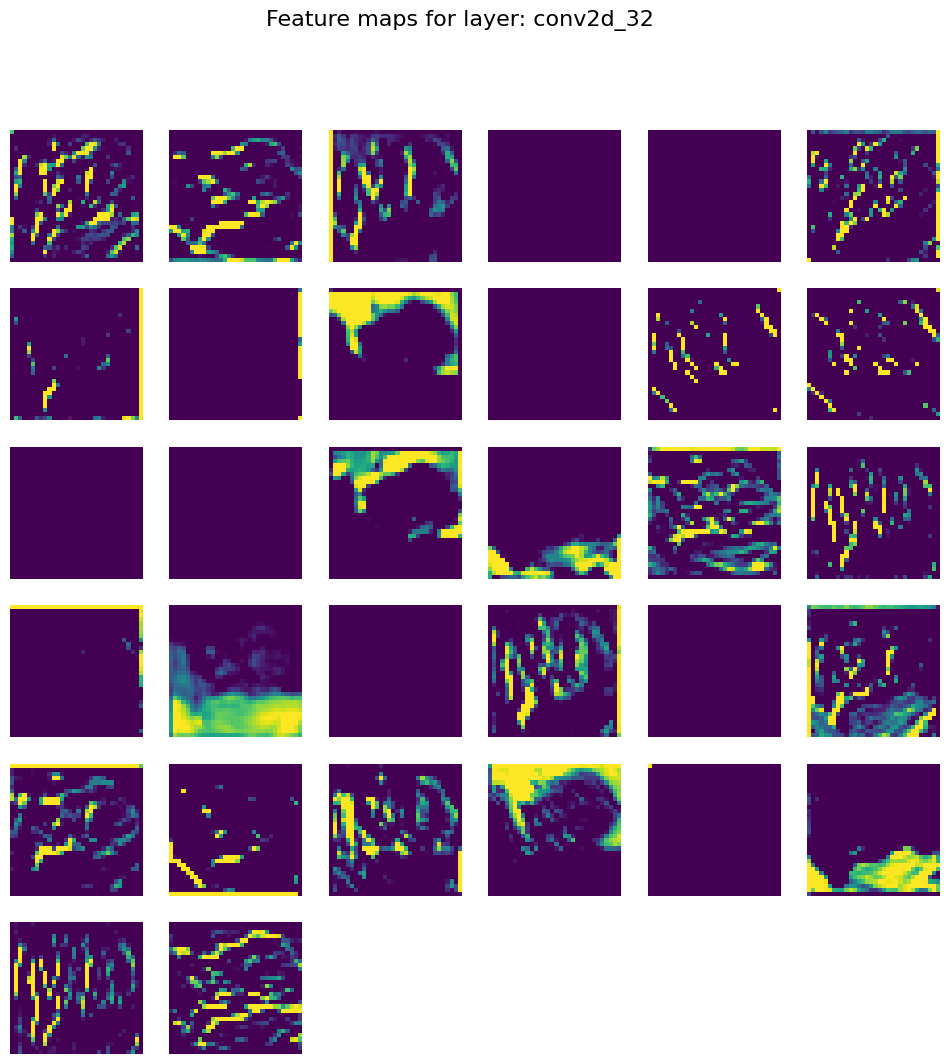

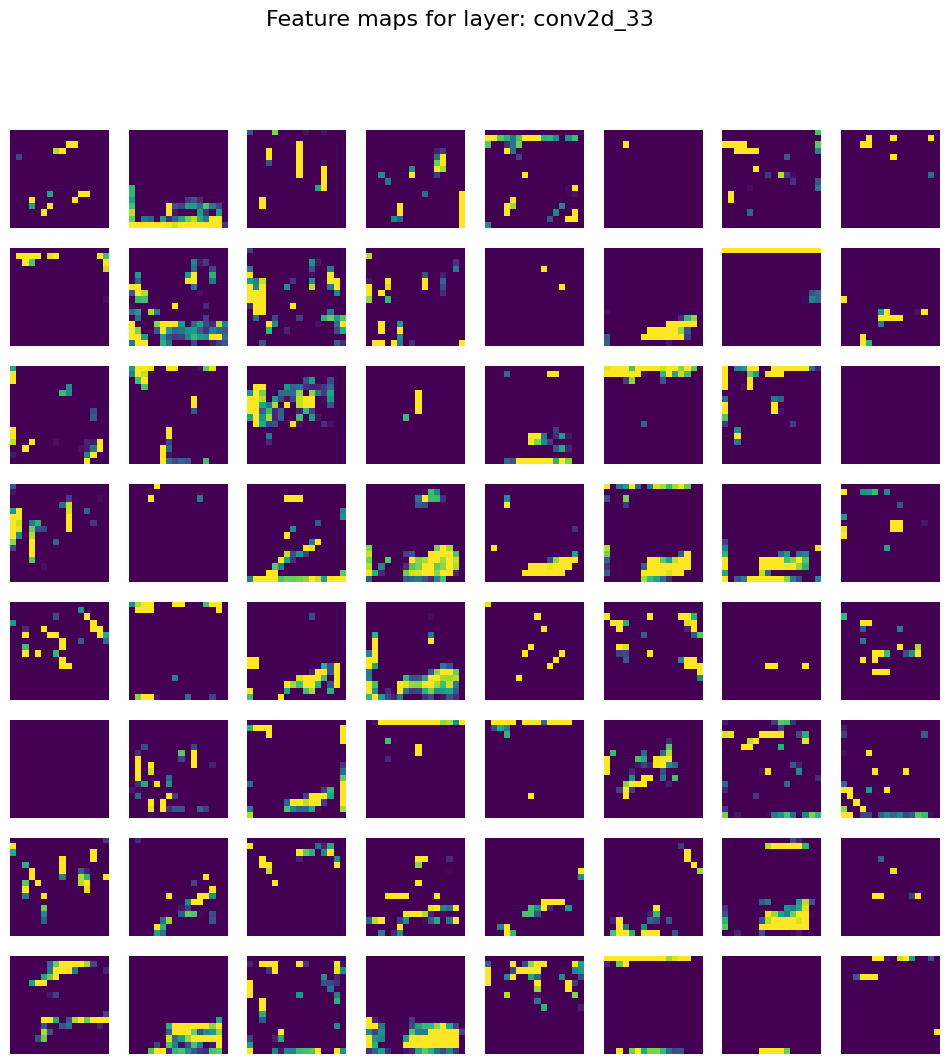

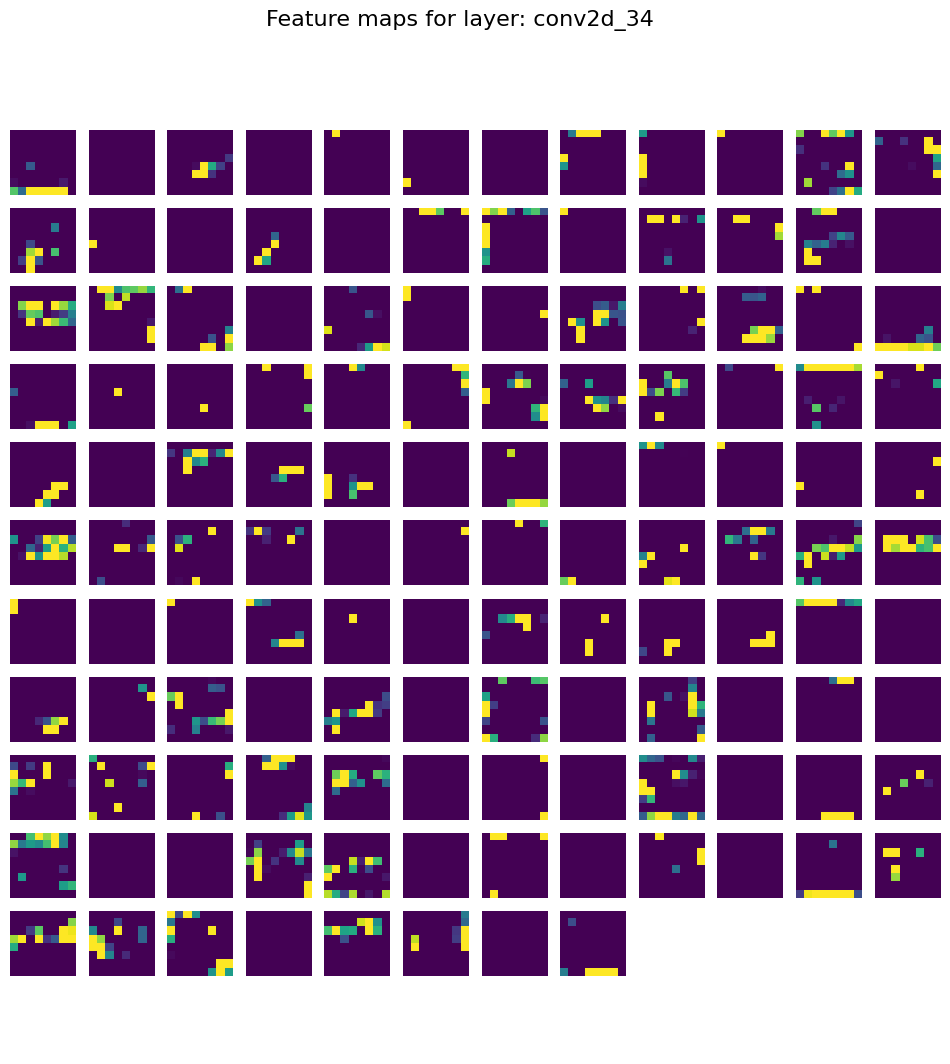

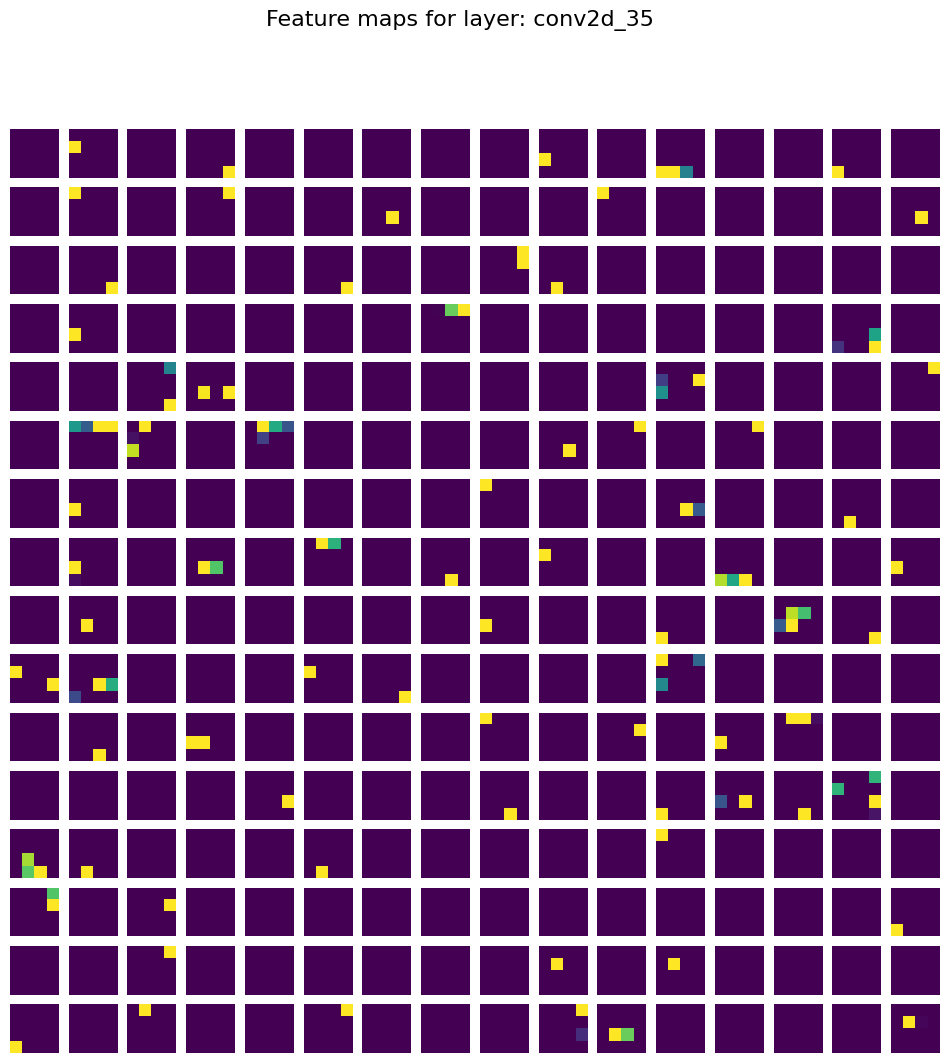

As the depth of the convolutional layers increases, the feature maps tend to become more abstract and less visually interpretable. The initial layers capture low-level features such as edges and textures, while the deeper layers capture high-level features and patterns that are more specific to the task at hand.


In [42]:
# Create a new model that outputs the feature maps of the intermediate layers
layer_outputs = [layer.output for layer in model_cifar10.layers if isinstance(layer, Conv2D)]
activation_model = tf.keras.models.Model(inputs=model_cifar10.input, outputs=layer_outputs)

# Get the feature maps for a sample image from the test set
sample_image = test_data[0]
sample_image = np.expand_dims(sample_image, axis=0)
feature_maps = activation_model.predict(sample_image)

# Plot the feature maps in a grid
for layer_name, feature_map in zip([layer.name for layer in model_cifar10.layers if isinstance(layer, Conv2D)], feature_maps):
    num_filters = feature_map.shape[-1]
    size = feature_map.shape[1]

  
    grid_size = int(np.ceil(np.sqrt(num_filters))) 

    fig, axs = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    fig.suptitle(f"Feature maps for layer: {layer_name}", fontsize=16)

    for i in range(num_filters):
        row, col = divmod(i, grid_size)
        ax = axs[row, col]
        
      
        x = feature_map[0, :, :, i]
        x -= x.mean()
        x /= (x.std() + 1e-5)  
        x *= 64
        x += 128
        x = np.clip(x, 0, 255).astype('uint8')
        
    
        ax.imshow(x, aspect='auto', cmap='viridis')
        ax.axis('off')
    

    for j in range(i + 1, grid_size * grid_size):
        row, col = divmod(j, grid_size)
        axs[row, col].axis('off')
    
    plt.show()



## **2.4**

Epoch 1/50
1407/1407 [==============================] - 22s 13ms/step - loss: 1.9887 - accuracy: 0.2992 - val_loss: 1.6725 - val_accuracy: 0.4294
Epoch 2/50
1407/1407 [==============================] - 21s 15ms/step - loss: 1.6885 - accuracy: 0.4281 - val_loss: 1.5823 - val_accuracy: 0.4690
Epoch 3/50
1407/1407 [==============================] - 29s 20ms/step - loss: 1.6037 - accuracy: 0.4744 - val_loss: 1.4651 - val_accuracy: 0.5320
Epoch 4/50
1407/1407 [==============================] - 30s 21ms/step - loss: 1.5448 - accuracy: 0.5069 - val_loss: 1.3629 - val_accuracy: 0.5750
Epoch 5/50
1407/1407 [==============================] - 30s 21ms/step - loss: 1.5010 - accuracy: 0.5301 - val_loss: 1.2898 - val_accuracy: 0.6138
Epoch 6/50
1407/1407 [==============================] - 30s 21ms/step - loss: 1.4659 - accuracy: 0.5544 - val_loss: 1.2930 - val_accuracy: 0.6192
Epoch 7/50
1407/1407 [==============================] - 15s 11ms/step - loss: 1.4368 - accuracy: 0.5722 - val_loss: 1.2130 -

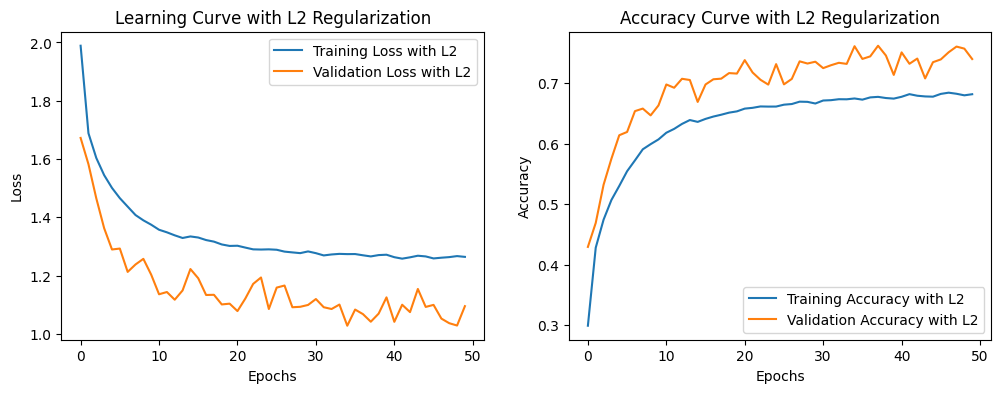

313/313 [==============================] - 1s 3ms/step - loss: 1.1233 - accuracy: 0.7231
Test Loss with L2: 1.1232799291610718
Test Accuracy with L2: 0.7231000065803528


In [50]:
from tensorflow.keras.regularizers import l2

# Define the CNN architecture with L2 regularization for CIFAR-10
def create_cnn_model_cifar10_with_l2(filter_size, stride_size, l2_lambda):
    input_layer = Input(shape=(32, 32, 3))
    x = Conv2D(32, kernel_size=filter_size, strides=stride_size, activation='relu', padding='same', kernel_regularizer=l2(l2_lambda))(input_layer)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    x = Conv2D(64, kernel_size=filter_size, strides=stride_size, activation='relu', padding='same', kernel_regularizer=l2(l2_lambda))(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    x = Conv2D(128, kernel_size=filter_size, strides=stride_size, activation='relu', padding='same', kernel_regularizer=l2(l2_lambda))(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    x = Conv2D(256, kernel_size=filter_size, strides=stride_size, activation='relu', padding='same', kernel_regularizer=l2(l2_lambda))(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(l2_lambda))(x)
    x = Dropout(0.5)(x)
    output_layer = Dense(10, activation='softmax', kernel_regularizer=l2(l2_lambda))(x)
    
    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
    return model

# Compile the model with L2 regularization
l2_lambda = 0.001
model_cifar10_l2 = create_cnn_model_cifar10_with_l2(filter_size, stride_size, l2_lambda)
model_cifar10_l2.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model with L2 regularization
history_cifar10_l2 = model_cifar10_l2.fit(train_data, train_labels, epochs=50, validation_data=(val_data, val_labels))

# Plot the learning curve with L2 regularization
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_cifar10_l2.history['loss'], label='Training Loss with L2')
plt.plot(history_cifar10_l2.history['val_loss'], label='Validation Loss with L2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curve with L2 Regularization')

plt.subplot(1, 2, 2)
plt.plot(history_cifar10_l2.history['accuracy'], label='Training Accuracy with L2')
plt.plot(history_cifar10_l2.history['val_accuracy'], label='Validation Accuracy with L2')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve with L2 Regularization')
plt.show()

# Evaluate the model with L2 regularization on the test set
test_loss_cifar10_l2, test_accuracy_cifar10_l2 = model_cifar10_l2.evaluate(test_data, test_labels)
print(f'Test Loss with L2: {test_loss_cifar10_l2}')
print(f'Test Accuracy with L2: {test_accuracy_cifar10_l2}')